<a href="https://colab.research.google.com/github/iThaysCambi/Generation-Exercicios/blob/main/importar_dados_kaggle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# base da dados do Kaggle para portifólio

import kagglehub
import pandas as pd
import os

# caminho da informação

base_dados = input('informe o local da base: ')
caminho_pasta = kagglehub.dataset_download(base_dados)

# lista todos as pastas do diretório
arquivos = os.listdir(caminho_pasta)

# lê e organiza todos os dados

arquivo_csv = [f for f in arquivos if f.endswith('.csv')][0]
caminho_completo = os.path.join(caminho_pasta, arquivo_csv)
df = pd.read_csv(caminho_completo)

nome_arquivo = input('informe o nome que você quer salvar o arquivo: ')

df.to_csv(nome_arquivo, index=False)

informe o local da base: ashishkumarak/netflix-reviews-playstore-daily-updated
Using Colab cache for faster access to the 'netflix-reviews-playstore-daily-updated' dataset.
informe o nome que você quer salvar o arquivo: Netiflix.csv


In [11]:
# para configurar ddos e ver eles devemos usar:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# configurar os visuais de maneira padrão
sns.set_theme(style='whitegrid')


In [13]:
# carregar dados
df_netiflix = pd.read_csv('/content/Netiflix.csv')
df_netiflix.info()  # para compreender a base de dados


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151525 entries, 0 to 151524
Data columns (total 8 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   reviewId              151525 non-null  object
 1   userName              151523 non-null  object
 2   content               151519 non-null  object
 3   score                 151525 non-null  int64 
 4   thumbsUpCount         151525 non-null  int64 
 5   reviewCreatedVersion  124096 non-null  object
 6   at                    151525 non-null  object
 7   appVersion            124096 non-null  object
dtypes: int64(2), object(6)
memory usage: 9.2+ MB


In [14]:
# se eu quero ver a base de dados
df_netiflix.head(3)

,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
0,4afc7d4f-5ccd-4f15-8096-aed195dec9af,Josue Joseph,let Michael Jackson rest in peace 🙏🏽,1,0,NaN,2026-05-27 09:15:17,NaN
1,488fbd96-f4d9-4f92-a330-f92c74f046a0,Oyan Mojumdar,ok,5,0,9.66.0 build 13 64116,2026-05-27 09:11:16,9.66.0 build 13 64116
2,454bbc93-74c3-41df-9693-6b0fc2fa0798,KIRTISIVA,Great performance and high-quality streaming m...,5,0,9.62.0 build 8 64020,2026-05-27 08:56:45,9.62.0 build 8 64020


/tmp/ipykernel_7211/1525043919.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_netiflix, x= 'score', palette='viridis')


Text(0.5, 1.0, 'Distribuição de notas')

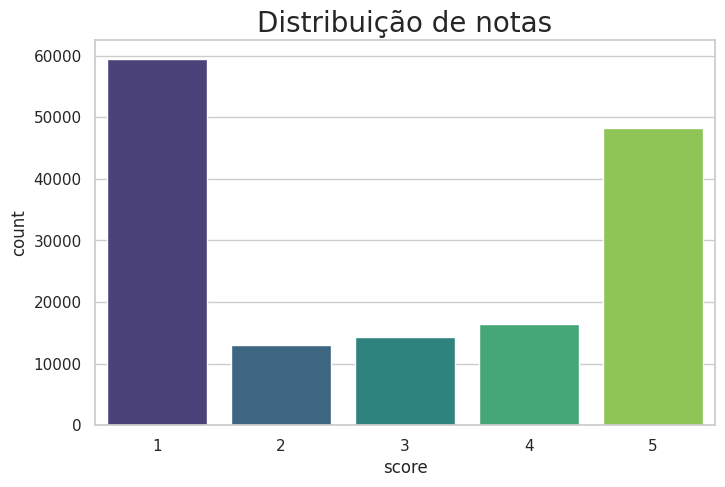

In [15]:
from ipywidgets.widgets.trait_types import date_from_json
# criar um gráfico para mostrar a distribuição de notas
plt.figure(figsize=(8,5))
ax = sns.countplot(data=df_netiflix, x= 'score', palette='viridis')

plt.title('Distribuição de notas', fontsize=20)

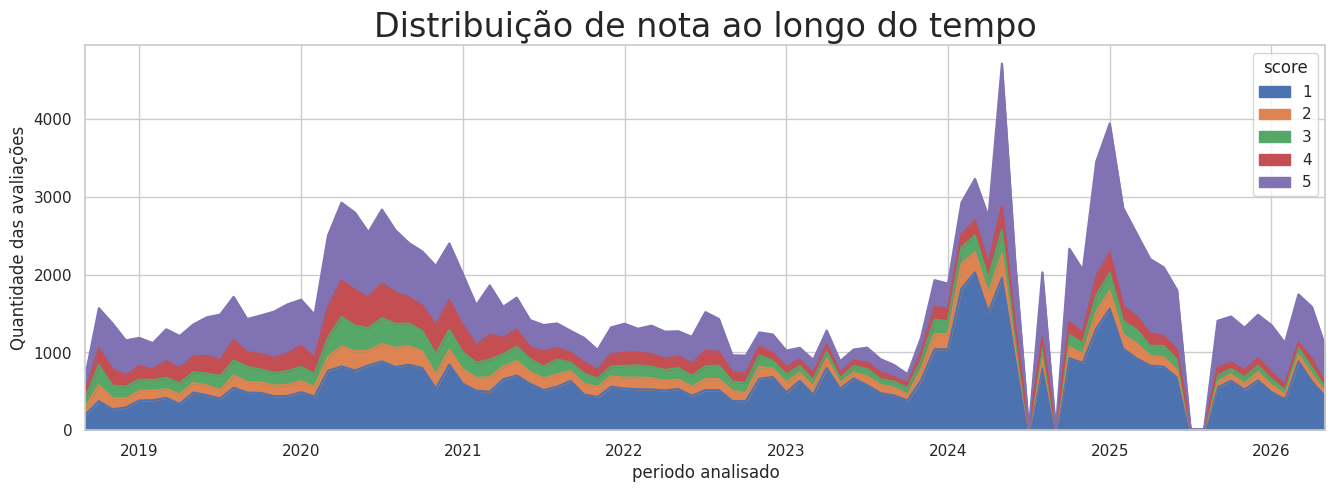

In [17]:
# força um campo a virar uma data
df_netiflix['at'] = pd.to_datetime(df_netiflix['at'])

# coleta apenas a informação ANO e MES do campo data
df_netiflix['ano_mes'] = df_netiflix['at'].dt.to_period('M')

# a evolução das notas do decorrer do periodo analisado
score_mensal = df_netiflix.groupby(['ano_mes', 'score']).size().unstack(fill_value=0)

score_mensal.plot(kind='area', figsize=(16,5))
plt.title('Distribuição de nota ao longo do tempo', fontsize=24)
plt.ylabel('Quantidade das avaliações')
plt.xlabel('periodo analisado')

plt.show()